# Modelos de IA do bot de checagem: execução e avaliação

**Frente de Modelos de IA** · RES IA ELD UnB, Turma 2 · 09/10/2026

O bot recebe uma mensagem sobre as eleições e tem duas camadas de inteligência:

| Camada | Pergunta | Modelo | Treinado por nós? |
| --- | --- | --- | --- |
| 1. Busca de checagens | "Isso já foi checado por uma agência?" | `paraphrase-multilingual-MiniLM-L12-v2` (embeddings) + similaridade de cosseno | Não, é pré-treinado; calibramos os limites |
| 2. Sinais de alerta | "Sem checagem, o texto tem cara de desinformação?" | TF-IDF + regressão logística | Sim |

Este notebook **carrega os modelos salvos, executa e avalia** as duas camadas com as métricas
definidas nos requisitos (RNF-02 a RNF-05, RNF-10). Ele não reimplementa nada: chama o pacote
`src/inteligencia/`, que é o mesmo código que o bot usa.

**Na pasta da entrega (zip)**, sem as bases de dados, rodam as seções 2 (camada 1) e 3.1 (inferência
da camada 2). As seções que avaliam no conjunto de teste precisam das bases, geradas no repositório.
Como o notebook foi salvo **já executado**, todas as saídas estão visíveis sem rodar nada.

**Pré-requisitos para rodar tudo** (a partir da raiz do repositório):

```bash
python -m venv .venv && source .venv/bin/activate
pip install -e '.[test,busca]' 'dvc>=3,<4' matplotlib jupyter
dvc repro          # baixa os dados, gera as bases, o índice da camada 1 e o modelo da camada 2
```

In [1]:
import os
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")   # sem barras de progresso do Hugging Face
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
import logging; logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
import json, hashlib, platform, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, yaml

# Raiz: o repositório (tem dvc.yaml) ou, fora dele, a pasta da entrega (tem params.yaml)
_acima = [Path.cwd(), *Path.cwd().parents]
RAIZ = next((p for p in _acima if (p / "dvc.yaml").exists()), None) or next(p for p in _acima if (p / "params.yaml").exists())
sys.path.insert(0, str(RAIZ / "src"))
print(f"Raiz: {RAIZ}")

from inteligencia import busca, calibracao, classificador, treino

PARAMS = yaml.safe_load((RAIZ / "params.yaml").read_text(encoding="utf-8"))
AZUL, LARANJA, CINZA = "#2a78d6", "#eb6834", "#a3a29c"   # verdadeira / falsa / neutro
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e0", "axes.axisbelow": True})

def sha256(caminho):
    return hashlib.sha256(Path(caminho).read_bytes()).hexdigest()[:16] + "…"

print(f"Python {platform.python_version()} · scikit-learn {sklearn.__version__} · numpy {np.__version__}")
print(f"Semente: {PARAMS['semente']}")

Raiz: /Users/aluno2/Residencia/RES-IA-Challenge-1
Python 3.14.6 · scikit-learn 1.9.1 · numpy 2.5.3
Semente: 42


## 1. Dados

As bases são geradas pela frente de Dados (`src/checagens/bases/`, documentadas em `docs/dados.md`)
a partir de datasets públicos, com versão e sha256 conferidos no download.

- **Base de checagens** (camada 1): títulos de checagens de agências, com o veredito da agência.
- **Base de treino** (camada 2): textos rotulados como falso ou verdadeiro, já divididos no tempo:
  treino até 15/09/2018, teste com mensagens de WhatsApp de 16/09 a 28/10/2018.

In [2]:
checagens = json.loads((RAIZ / "data/processados/checagens/checagens.json").read_text(encoding="utf-8"))
ch = pd.DataFrame(checagens)
print(f"Base de checagens: {len(ch):,} registros · {ch['data'].min()} a {ch['data'].max()} · sha256 {sha256(RAIZ / 'data/processados/checagens/checagens.json')}")
pd.crosstab(ch["fonte_dataset"], ch["veredito_normalizado"], margins=True, margins_name="total")

Base de checagens: 10,442 registros · 2013-07-02 a 2022-12-01 · sha256 fad1245d2ebd5422…


veredito_normalizado,enganoso,falso,outro,verdadeiro,total
fonte_dataset,,,,,
FACTCK.BR,75,756,21,33,885
FactChecks.br/Central de Fatos,21,6994,0,20,7035
FactChecks.br/FakeRecogna,16,702,0,0,718
FactPolCheckBr,3,1792,0,9,1804
total,115,10244,21,62,10442


In [3]:
bases = {n: pd.read_csv(RAIZ / f"data/processados/treino/{n}.csv", keep_default_na=False)
         for n in ("treino", "teste", "teste_curtos")}
resumo = pd.concat({n: d.groupby(["fonte", "rotulo"]).size().unstack(fill_value=0) for n, d in bases.items()})
resumo["% falso"] = (100 * resumo["falso"] / resumo.sum(axis=1)).round(1)
for n in bases:
    print(f"{n:13s} sha256 {sha256(RAIZ / f'data/processados/treino/{n}.csv')}")
resumo

treino        sha256 06775ea8c2e9d1de…
teste         sha256 df42ca7f9e8bf621…
teste_curtos  sha256 8600a3e6c3e4115b…


rotulo                        falso  verdadeiro  % falso
             fonte                                      
treino       Fake.br-Corpus    3600        3599     50.0
             FakeWhatsApp.Br   1162        1573     42.5
teste        FakeWhatsApp.Br   1628        1667     49.4
teste_curtos FakeTweet.Br       199          98     67.0

## 2. Camada 1: busca de checagens

**Como funciona.** Cada checagem da base vira um vetor de 384 números (embedding) gerado pelo
MiniLM multilíngue. Textos com sentido parecido têm vetores próximos. A cada mensagem:

1. a consulta é normalizada: apelidos e internetês por dicionário ("Xandão" → "Alexandre de
   Moraes", "ñ" → "não");
2. vira um vetor com o mesmo modelo;
3. é comparada com todas as checagens. Como os vetores são normalizados, o cosseno é o produto
   escalar;
4. a semelhança do 1º colocado define a faixa (RN-05): `ja_checado` (≥ limite alto),
   `relacionada` (entre os limites) ou `baixa`;
5. se só um dos textos tem negação ("não", "nunca"…), `ja_checado` cai para `relacionada` (RN-06).

**O que foi "treinado".** O modelo é pré-treinado. Na comparação preliminar com 6 candidatos
(`experiments/06_modelos.ipynb`), ele empatou com os outros quando a consulta é normalizada (MRR
0,917 contra 0,909 a 0,929) e foi o mais rápido. Sem normalização, ficou em último. O que ajustamos
foram os **dois limites**, calibrados no benchmark de 62 casos (`data/testes_benchmark.json`).

In [4]:
vetores, registros = busca.carregar_indice(busca.INDICE_PADRAO)   # confere o sha256 dos arquivos
alta, media = busca.ler_limites()
manifesto = json.loads((busca.INDICE_PADRAO / "manifesto.json").read_text())
print(f"Índice: {vetores.shape[0]:,} checagens × {vetores.shape[1]} dimensões")
print(f"Modelo: {manifesto['modelo']} (revisão {manifesto['revisao'][:8]})")
print(f"Limites calibrados (params.yaml): alto {alta:.2f} · médio {media:.2f}")
buscador = busca.Buscador(vetores, registros, alta, media)

Índice: 10,442 checagens × 384 dimensões
Modelo: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 (revisão e8f8c211)
Limites calibrados (params.yaml): alto 0.86 · médio 0.76


### 2.1 Inferência: exemplos

In [5]:
exemplos = [
    "Xandão recebeu 60 milhões do Molusco para fraudar as urnas",   # apelidos
    "vcs viram q o ibge ta usando celular pra roubar biometria??",   # internetês
    "Lula NÃO disse que vai acabar com o Pix",                       # negação
    "Prefeitura inaugura nova escola no bairro",                      # notícia sem relação
]
linhas = []
for texto in exemplos:
    r = buscador.buscar(texto, k=1)[0]
    linhas.append({"mensagem": texto, "consulta normalizada": buscador.preparar_consulta(texto),
                   "checagem mais parecida": r["alegacao"][:70], "semelhança": r["semelhanca"],
                   "faixa": r["faixa"], "veredito da agência": r["veredito_original"]})
pd.set_option("display.max_colwidth", 80)
pd.DataFrame(linhas)

/Users/aluno2/Residencia/RES-IA-Challenge-1/.venv-1/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,mensagem,consulta normalizada,checagem mais parecida,semelhança,faixa,veredito da agência
0,Xandão recebeu 60 milhões do Molusco para fraudar as urnas,Alexandre de Moraes recebeu 60 milhões do Lula para fraudar as urnas,Alexandre de Moraes recebeu R$ 60 milhões de Lula para fraudar urnas n,0.9728,ja_checado,Falsa
1,vcs viram q o ibge ta usando celular pra roubar biometria??,vocês viram que o ibge está usando celular para roubar biometria??,IBGE tem celular com urna eletrônica para roubar biometria de eleitore,0.7023,baixa,Falsa
2,Lula NÃO disse que vai acabar com o Pix,Lula NÃO disse que vai acabar com o Pix,Lula não disse que vai rever ou acabar com o PIX,0.9127,ja_checado,Falsa
3,Prefeitura inaugura nova escola no bairro,Prefeitura inaugura nova escola no bairro,"Escola Anne Sullivan, em São Paulo, vai fechar por falta de alunos",0.4613,baixa,#boato


### 2.2 Avaliação no benchmark

O benchmark tem 62 mensagens:
- **24 reescritas** de boatos checados: gíria, apelido, erro ortográfico e recorrência temporal;
- **6 negações**;
- **32 controles**, que são notícias reais do g1 e não deveriam receber checagem.

| Métrica | Requisito | Meta |
| --- | --- | --- |
| Checagem certa entre as 3 primeiras nas 24 reescritas | RNF-04 | ≥ 70% |
| Controles mostrados como "já checado" | RNF-05 | ≤ 2 de 32 |
| Controles com alguma checagem mostrada | critério interno | ≤ 8 de 32 |

In [6]:
casos = json.loads(calibracao.BENCHMARK.read_text(encoding="utf-8"))
d = calibracao.preparar(buscador, casos)
d_sem_norm = calibracao.preparar(busca.Buscador(vetores, registros, alta, media, normalizar=None), casos)
m = calibracao.avaliar(d, alta, media)
top3_sem = calibracao.avaliar(d_sem_norm, alta, media)["reescritas_top3"]

print(f"RNF-04 · top-3 nas reescritas: {m['reescritas_top3']:.0%} (meta ≥ 70%) · sem normalização: {top3_sem:.0%}")
print(f"RNF-05 · controles em 'já checado': {m['controles_ja_checado']} de 32 (meta ≤ 2)")
print(f"Interno · controles com alguma checagem: {m['controles_mostrados']} de 32 (meta ≤ 8)")
print(f"Reescritas com a checagem certa MOSTRADA ao usuário: {m['reescritas_mostradas']:.0%}")
print(f"Negações em 'já checado': {m['negacao_ja_checado']} de 6")

reescritas = d[d["tipo"].isin(calibracao.REESCRITAS)]
(reescritas.assign(top3=reescritas["posicao_certa"] <= 3)
 .groupby("tipo")["top3"].agg(["sum", "count"]).rename(columns={"sum": "no top-3", "count": "casos"}))

RNF-04 · top-3 nas reescritas: 71% (meta ≥ 70%) · sem normalização: 67%
RNF-05 · controles em 'já checado': 0 de 32 (meta ≤ 2)
Interno · controles com alguma checagem: 2 de 32 (meta ≤ 8)
Reescritas com a checagem certa MOSTRADA ao usuário: 38%
Negações em 'já checado': 0 de 6


,no top-3,casos
tipo,,
apelido,5,6
erro_ortografico,6,6
giria,3,6
recorrencia_temporal,3,6


### 2.3 O dilema dos limites

Baixar o limite médio mostra a checagem certa em mais boatos, mas também mostra uma checagem sem
relação para notícias reais. A curva abaixo vem da varredura de todos os pares de limites. Os
limites escolhidos (ponto marcado) respeitam a RNF-05 e o teto interno de 8 notícias reais.

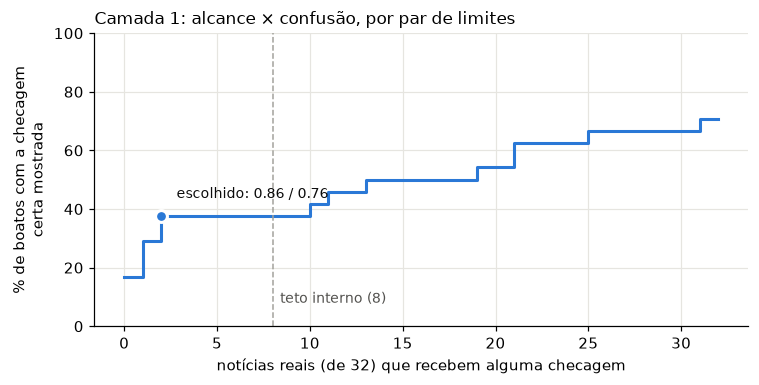

In [7]:
g = calibracao.grade(d)
fronteira = (g[g["controles_ja_checado"] <= 2].groupby("controles_mostrados")["reescritas_mostradas"]
             .max().cummax().reset_index())
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(fronteira["controles_mostrados"], 100 * fronteira["reescritas_mostradas"], color=AZUL, lw=2,
        drawstyle="steps-post")
ax.axvline(calibracao.MAX_CONTROLES_MOSTRADOS, color=CINZA, lw=1, ls="--")
ax.text(calibracao.MAX_CONTROLES_MOSTRADOS + 0.4, 8, "teto interno (8)", color="#52514e", fontsize=9)
ax.scatter([m["controles_mostrados"]], [100 * m["reescritas_mostradas"]], s=60, color=AZUL,
           edgecolor="white", linewidth=2, zorder=3)
ax.annotate(f"escolhido: {alta:.2f} / {media:.2f}", (m["controles_mostrados"], 100 * m["reescritas_mostradas"]),
            xytext=(10, 12), textcoords="offset points", fontsize=9, color="#0b0b0b")
ax.set_xlabel("notícias reais (de 32) que recebem alguma checagem")
ax.set_ylabel("% de boatos com a checagem\ncerta mostrada")
ax.set_title("Camada 1: alcance × confusão, por par de limites", loc="left", fontsize=11)
ax.set_ylim(0, 100)
plt.tight_layout(); plt.show()

### 2.4 Casos de negação (RN-06)

In [8]:
neg = calibracao.casos_com_faixa(d, alta, media)
neg[neg["tipo"] == "negacao"][["texto", "alegacao_topo", "s_topo", "faixa_topo"]].round(3)

,texto,alegacao_topo,s_topo,faixa_topo
50,Lula NÃO prometeu acabar com o Pix em reunião com banqueiros.,Lula não disse que vai rever ou acabar com o PIX,0.858,relacionada
51,A rede de lojas Renner NÃO declarou apoio oficial ao PT nem fechou parceria.,TSE não trocou empresa responsável pela divulgação da apuração,0.645,baixa
52,Anitta NÃO retirou o apoio à candidatura nem mudou de lado.,Damares não cancelou indenizações de anistiados políticos,0.586,baixa
53,A TV Cultura confirmou que o salário de Vera Magalhães NÃO é de R$ 500 mil.,Salário anual de Vera Magalhães na TV Cultura não é de R$ 500 mil; é de quas...,0.656,baixa
54,Lula NÃO declarou em entrevista que o agronegócio deve ser eliminado.,Lula não disse que irá colocar ‘caminhoneiros em seu devido lugar’,0.802,relacionada
55,O Museu Imperial NÃO ocultou o nome do governo federal nos guias.,Museu Imperial oculta o nome do governo em guia de visitação para prejudicar...,0.577,baixa


**Leitura da camada 1.**
- O top-3 atende à RNF-04, com pouca margem. A normalização da consulta ajuda: sem ela, o
  top-3 fica abaixo da meta. Os dicionários de apelidos foram montados depois do benchmark, então
  parte desse ganho é otimista.
- Nenhuma notícia real recebe "já checado", que é o erro mais grave para o usuário.
- O custo da prudência é o alcance: a checagem certa é mostrada em cerca de 4 de cada 10 boatos
  reescritos, embora esteja no top-3 em 7 de cada 10.

## 3. Camada 2: classificador de sinais de alerta

**Como funciona.**
- O **TF-IDF** transforma o texto em pesos de palavras e pares de palavras: palavras raras na base
  pesam mais.
- A **regressão logística** combina esses pesos numa probabilidade de a mensagem ser falsa.
- Dois **cortes**, escolhidos só com o treino por validação cruzada, transformam a probabilidade em
  faixa: `muitos_sinais`, `incerto` ou `poucos_sinais`.
- Os **sinais** mostrados são as palavras do texto com maior contribuição (TF-IDF × peso).

**Critério de decisão, escrito antes de rodar o teste** (`docs/relatorio-camada2.md`): `go` se
F1 macro ≥ 0,75 (RNF-02), falso alarme ≤ 15% (RNF-03) e pelo menos 100 textos de cada classe no
teste. Falso alarme = fração das mensagens **verdadeiras** que caem em `muitos_sinais`.

In [9]:
clf = classificador.Classificador.carregar()      # models/classificador.joblib
print(f"Modelo: {clf.pipeline}")
print(f"Vocabulário: {len(clf.pipeline.named_steps['tfidf'].vocabulary_):,} termos · "
      f"cortes das faixas: alto {clf.corte_alto:.3f} · baixo {clf.corte_baixo:.3f}")
print("Parâmetros (params.yaml):", PARAMS["camada2"])

Modelo: Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 strip_accents='unicode')),
                ('lr',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])
Vocabulário: 171,645 termos · cortes das faixas: alto 0.527 · baixo 0.483
Parâmetros (params.yaml): {'ngram_range': [1, 2], 'min_df': 2, 'C': 1.0, 'max_iter': 1000, 'folds': 5, 'margem_faixas': 0.1}


### 3.1 Inferência: exemplos

In [10]:
for texto in ["URGENTE!!! Compartilhem antes que apaguem: as urnas foram fraudadas",
              "O TSE divulgou nesta terça-feira o calendário oficial das eleições",
              "Bom dia grupo, alguém sabe que horas abre a seção eleitoral?"]:
    print(f"{clf.classificar(texto)}  ←  {texto}")

{'faixa': 'muitos_sinais', 'sinais': ['URGENTE', 'foram', 'Compartilhem']}  ←  URGENTE!!! Compartilhem antes que apaguem: as urnas foram fraudadas
{'faixa': 'poucos_sinais', 'sinais': ['nesta', 'feira', 'terça']}  ←  O TSE divulgou nesta terça-feira o calendário oficial das eleições
{'faixa': 'poucos_sinais', 'sinais': ['dia', 'Bom dia', 'alguém sabe']}  ←  Bom dia grupo, alguém sabe que horas abre a seção eleitoral?


Repare no 2º exemplo: a notícia oficial cai em `poucos_sinais`, mas os "sinais" são **"nesta",
"terça", "feira"**. O modelo reconhece o *jeito de jornal escrever datas*, não o conteúdo. É o
atalho de veículo, investigado na seção 3.3.

### 3.2 Avaliação no teste (WhatsApp, 16/09 a 28/10/2018)

In [11]:
tr = treino.carregar_csv(RAIZ / "data/processados/treino/treino.csv")
te, rep = treino.remover_repetidos(tr, treino.carregar_csv(RAIZ / "data/processados/treino/teste.csv"))
metricas = treino.avaliar(clf, tr, te, PARAMS["semente"])

tabela = pd.DataFrame([
    ["F1 macro", f"{metricas['f1_macro']:.3f}", "≥ 0,75 (RNF-02)", metricas["f1_macro"] >= treino.F1_MINIMO],
    ["Falso alarme", f"{metricas['falso_alarme']:.1%}", "≤ 15% (RNF-03)", metricas["falso_alarme"] <= treino.FALSO_ALARME_MAXIMO],
    ["Falsas / verdadeiras no teste", f"{metricas['teste']['falsas']} / {metricas['teste']['verdadeiras']}", "≥ 100 / ≥ 100",
     min(metricas["teste"].values()) >= treino.MINIMO_POR_CLASSE],
], columns=["métrica", "valor", "condição", "atende"])
print(f"DECISÃO: {metricas['decisao'].upper()}  ·  {'; '.join(metricas['motivos_no_go'])}")
tabela

DECISÃO: NO-GO  ·  F1 macro 0.673 < 0.75 (RNF-02); falso alarme 30.8% > 15% (RNF-03)


,métrica,valor,condição,atende
0,F1 macro,0.673,"≥ 0,75 (RNF-02)",False
1,Falso alarme,30.8%,≤ 15% (RNF-03),False
2,Falsas / verdadeiras no teste,1628 / 1667,≥ 100 / ≥ 100,True


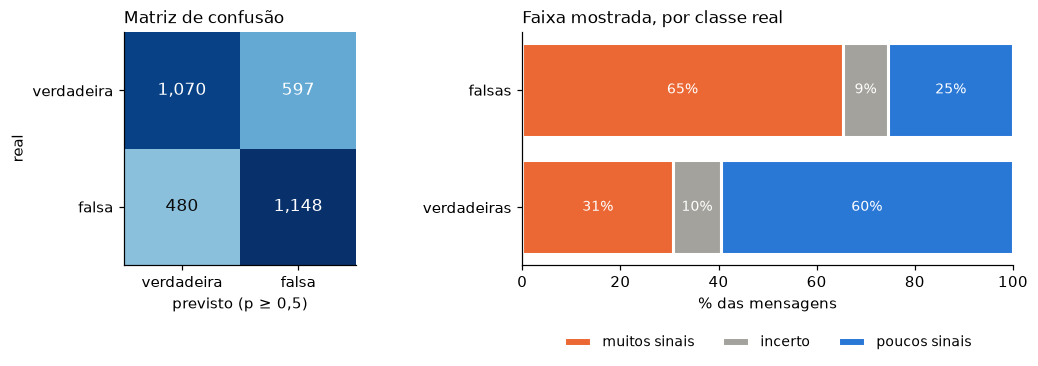

Falso alarme = 513 de 1667 verdadeiras em 'muitos sinais'


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1, 1.4]})

mc = np.array(metricas["matriz_confusao"]["valores"])
ax1.imshow(mc, cmap="Blues", vmin=0)
for (i, j), v in np.ndenumerate(mc):
    ax1.text(j, i, f"{v:,}", ha="center", va="center", fontsize=11, color="white" if v > mc.max() / 2 else "#0b0b0b")
ax1.set_xticks([0, 1], ["verdadeira", "falsa"]); ax1.set_yticks([0, 1], ["verdadeira", "falsa"])
ax1.set_xlabel("previsto (p ≥ 0,5)"); ax1.set_ylabel("real"); ax1.grid(False)
ax1.set_title("Matriz de confusão", loc="left", fontsize=11)

faixas = pd.DataFrame(metricas["faixas_por_classe"]).T[list(classificador.FAIXAS)]
pct = 100 * faixas.div(faixas.sum(axis=1), axis=0)
esquerda = np.zeros(len(pct))
for faixa, cor in zip(classificador.FAIXAS, [LARANJA, CINZA, AZUL]):
    ax2.barh(pct.index, pct[faixa], left=esquerda, color=cor, edgecolor="white", linewidth=2, label=faixa.replace("_", " "))
    for y, (x0, w) in enumerate(zip(esquerda, pct[faixa])):
        if w > 6:
            ax2.text(x0 + w / 2, y, f"{w:.0f}%", ha="center", va="center", fontsize=9, color="white")
    esquerda += pct[faixa].to_numpy()
ax2.set_xlim(0, 100); ax2.set_xlabel("% das mensagens"); ax2.grid(False)
ax2.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=False, fontsize=9)
ax2.set_title("Faixa mostrada, por classe real", loc="left", fontsize=11)
plt.tight_layout(); plt.show()
print(f"Falso alarme = {faixas.loc['verdadeiras', 'muitos_sinais']} de {faixas.loc['verdadeiras'].sum()} verdadeiras em 'muitos sinais'")

### 3.3 Por que não passou: o modelo aprendeu o veículo

Os termos com maior peso mostram **o que** o modelo aprendeu. A frente de Dados já tinha alertado
(`docs/dados.md`, "Limitações"): no Fake.br, 72% do treino, as notícias verdadeiras são texto de
jornal, e as falsas vêm de outros sites.

In [13]:
nomes = clf.pipeline.named_steps["tfidf"].get_feature_names_out()
coef = clf.pipeline.named_steps["lr"].coef_[0]
ordem = np.argsort(coef)
pd.DataFrame({"puxam para FALSA": nomes[ordem[-15:]][::-1], "peso +": coef[ordem[-15:]][::-1].round(2),
              "puxam para VERDADEIRA": nomes[ordem[:15]], "peso −": coef[ordem[:15]].round(2)})

,puxam para FALSA,peso +,puxam para VERDADEIRA,peso −
0,dilma,4.88,feira,-6.38
1,lula,4.85,nesta,-5.83
2,disse,4.26,mas,-3.59
3,video,3.64,em,-3.17
4,esta,3.59,segundo,-3.14
5,um,3.27,quarta,-3.08
6,nao,2.99,diz,-3.00
7,globo,2.89,terca,-2.83
8,que,2.89,tribunal,-2.71
9,foi,2.82,quarta feira,-2.59


Os termos de "verdadeira" são de **estilo jornalístico** ("nesta quarta-feira", "segundo",
"tribunal", "g1"), não de conteúdo. Mensagens verdadeiras de WhatsApp não têm esse estilo e caem
como falsas, o que explica os 31% de falso alarme.

### 3.4 Relato complementar (não entra na decisão)

In [14]:
cu, _ = treino.remover_repetidos(tr, treino.carregar_csv(RAIZ / "data/processados/treino/teste_curtos.csv"))
extra = treino.avaliar(clf, tr, cu, PARAMS["semente"])
pd.DataFrame({
    "teste (WhatsApp 2018)": [metricas["f1_macro"], metricas["falso_alarme"], sum(metricas["teste"].values())],
    "teste extra (tweets 2010–2019)": [extra["f1_macro"], extra["falso_alarme"], sum(extra["teste"].values())],
    "linha de base: classe majoritária": [metricas["complementar"]["linha_de_base_majoritaria_f1"], None, None],
}, index=["F1 macro", "falso alarme", "textos"]).round(3)

,teste (WhatsApp 2018),teste extra (tweets 2010–2019),linha de base: classe majoritária
F1 macro,0.673,0.584,0.336
falso alarme,0.308,0.378,NaN
textos,3295.000,297.000,NaN


## 4. Reprodutibilidade (RNF-10)

O treino usa semente fixa, e os cortes das faixas saem de validação cruzada estratificada com a
mesma semente. Treinar de novo com os mesmos dados e parâmetros tem que dar **exatamente** as
métricas salvas em `experiments/results/metricas_camada2.json` pelo `dvc repro treinar`.

In [15]:
novo = treino.treinar(tr, PARAMS)
salvas = json.loads((RAIZ / "experiments/results/metricas_camada2.json").read_text(encoding="utf-8"))
refeitas = treino.avaliar(novo, tr, te, PARAMS["semente"])
iguais = all(refeitas[k] == salvas[k] for k in ("f1_macro", "falso_alarme", "matriz_confusao", "cortes", "decisao"))
print(f"Retreino reproduz as métricas salvas: {iguais}")

Retreino reproduz as métricas salvas: True


## 5. Conclusão

| Camada | Resultado | O bot |
| --- | --- | --- |
| 1. Busca | RNF-04 atende (top-3 ≥ 70%); RNF-05 atende (0 notícias reais como "já checado") | usa |
| 2. Classificador | **`no-go`**: F1 0,67 < 0,75 e falso alarme 31% > 15% | **não mostra** (RN-04): sem checagem, indica as agências |

O `no-go` foi decidido pelo critério escrito **antes** de rodar o teste. A análise acima explica o
motivo: o modelo aprendeu o estilo do veículo de origem, não sinais de desinformação. Um novo modelo
exigiria uma nova rodada, com critério e teste registrados antes. Detalhes e decisões estão no
relatório técnico.